In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
nnonspec = 0 
pdrop = 0.0 
drc = 0
code = "RS_q11_n10_k7_w4"


nbarcodes = 25
lf =1.0


input = [f"codebooks/{code}_cb.csv",
        f"truth/ground_truth_{code}_nbarcodes{nbarcodes}_nnonspec{nnonspec}_pdrop{pdrop}.csv",
        f"decoded_hstackfit/nc_decoded_{code}_nbarcodes{nbarcodes}_nnonspec{nnonspec}_pdrop{pdrop}_lf{lf}_drc{drc}.csv"]

In [3]:
input

['codebooks/RS_q11_n10_k7_w4_cb.csv',
 'truth/ground_truth_RS_q11_n10_k7_w4_nbarcodes25_nnonspec0_pdrop0.0.csv',
 'decoded_hstackfit/nc_decoded_RS_q11_n10_k7_w4_nbarcodes25_nnonspec0_pdrop0.0_lf1.0_drc0.csv']

In [4]:


cb = pd.read_csv(input[0]) 

n_codewords = len(cb)
n_ontargets = n_codewords - np.sum(cb.gene == "negative_control")

tfname = input[1]
dfname = input[2] 

ground_truth = pd.read_csv(tfname)
dcd_mpaths = pd.read_csv(dfname)

nreps = 100

In [5]:

def get_marge_vals(lambda_path):
    marge_fp = lambda_path["fp"][1:] - lambda_path["fp"][:-1]
    marge_fp = np.concatenate([[lambda_path["fp"].iloc[0]], marge_fp])
    marge_gebc = lambda_path["gene_encoding_barcodes"][1:] - lambda_path["gene_encoding_barcodes"][:-1]
    marge_gebc = np.concatenate([[lambda_path["gene_encoding_barcodes"].iloc[0]], marge_gebc])

    marge_ncbc = lambda_path["negative_control_barcodes"][1:] - lambda_path["negative_control_barcodes"][:-1]
    marge_ncbc = np.concatenate([[lambda_path["negative_control_barcodes"].iloc[0]], marge_ncbc])

    lambda_path.loc[:, "marge_fp"] = marge_fp
    lambda_path.loc[:, "marge_gene_encoding_barcodes"] = marge_gebc
    lambda_path.loc[:, "marge_negative_control_barcodes"] = marge_ncbc
    return lambda_path

def cum_sums(df):
    df.sort_values("lambda", ascending=False, inplace=True)
    df.loc[:, "fp_cumsum"] = np.cumsum(df["marge_fp"])
    df.loc[:, "gene_encoding_barcodes_cumsum"] = np.cumsum(df["marge_gene_encoding_barcodes"])
    df.loc[:, "negative_control_barcodes_cumsum"] = np.cumsum(df["marge_negative_control_barcodes"])
    return df

def get_eff_fdr_all_stringency(mpaths_all, truth):
    if len(mpaths_all) == 0:
        sum_stats = pd.DataFrame()
        sum_stats["lambda"] = np.nan
        sum_stats["n_barcodes"] = 0
        sum_stats["negative_control_barcodes"] = 0
        sum_stats["gene_encoding_barcodes"] = 0
        sum_stats["est_fp_rate"] = 0
        sum_stats["eff_truth"] = 0
        sum_stats["fdr_truth"] = 0
        sum_stats["fp"] = 0
        sum_stats["not_decoded_true"] = len(truth)
        sum_stats["total_true_cnts"] = len(truth)
        return sum_stats
    else:
        mpaths_all.reset_index(inplace=True, drop =True)
        mpaths_all.set_index("stringency_rank", inplace=True)
        stringency_stats = []
        n_codewords = len(cb)
        n_ontargets = n_codewords - np.sum(cb.gene == "negative_control")
        lambda_last = np.inf
    
        for stringency_rank in range(1, 101):
            if np.max(mpaths_all.index) < stringency_rank:
                break
            mpaths = mpaths_all.loc[mpaths_all.index <= stringency_rank]
            
            if mpaths.empty or lambda_last == np.unique(mpaths.loc[np.max(mpaths.index), "lambda"]):
                continue
            else:
                lambda_last = np.unique(mpaths.loc[np.max(mpaths.index), "lambda"])
                n_barcodes = len(mpaths)
                n_neg_cntrl_mpaths = np.sum(mpaths.gene == "negative_control")
                
                sum_stats = pd.DataFrame()
                sum_stats["stringency_rank"] = [stringency_rank]
    
                sum_stats["lambda"] = np.unique(mpaths.loc[np.max(mpaths.index), "lambda"])

                sum_stats.loc[:,"n_barcodes"] = [n_barcodes]
                sum_stats.loc[:,"negative_control_barcodes"] = [n_neg_cntrl_mpaths]
                sum_stats.loc[:,"gene_encoding_barcodes"] = [n_barcodes - n_neg_cntrl_mpaths]
                if (n_barcodes-n_neg_cntrl_mpaths) == 0: 
                    sum_stats.loc[:,"est_fp_rate"] = 1
                else:
                    sum_stats.loc[:,"est_fp_rate"] = [(n_neg_cntrl_mpaths*n_ontargets/(n_codewords-n_ontargets))/(n_barcodes-n_neg_cntrl_mpaths)]
                #print(truth)
                trth_cnts = truth.groupby("gene").size()
                total_trth_cnts = np.sum(trth_cnts)
                
                trth_cnts_df = pd.DataFrame({"truth": trth_cnts})
                
                dcd_cnts = mpaths.groupby("gene").size()
                dcd_cnts_df = pd.DataFrame({"decoded": dcd_cnts})
                dcd_cnts_df["truth"] = trth_cnts
                dcd_cnts_df.fillna(0, inplace=True)
                dcd_cnts_df["diff"] = dcd_cnts_df["truth"] - dcd_cnts_df["decoded"]
                
                fp = -np.sum(dcd_cnts_df["diff"].loc[dcd_cnts_df["diff"] <= 0]) -n_neg_cntrl_mpaths
                trth_cnts_df["decoded"] = dcd_cnts
                fdr = fp/np.sum(dcd_cnts)
                
                trth_cnts_df.fillna(0, inplace=True)
                
                trth_cnts_df["diff"] = trth_cnts_df["truth"] - trth_cnts_df["decoded"]
                
                not_decoded_true = np.sum(trth_cnts_df["diff"].loc[trth_cnts_df["diff"] >=0])
                eff = (total_trth_cnts - not_decoded_true)/total_trth_cnts
            
                sum_stats["eff_truth"] = eff
                sum_stats["fdr_truth"] = fdr
                sum_stats["fp"] = fp
                sum_stats["not_decoded_true"] = not_decoded_true
                sum_stats["total_true_cnts"] = total_trth_cnts
                
                stringency_stats.append(sum_stats)
        stats_concat = pd.concat(stringency_stats)
        stats_concat["rep"] = mpaths_all["rep"].iloc[0]
        stats_w_marge = get_marge_vals(stats_concat)
        return stats_w_marge


<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\l'
C:\Users\jonat\AppData\Local\Temp\ipykernel_35180\864669586.py:27: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel("$\lambda$")
C:\Users\jonat\AppData\Local\Temp\ipykernel_35180\1800784977.py:67: RuntimeWarning: invalid value encountered in scalar divide
  sum_stats.loc[:,"est_fp_rate"] = [(n_neg_cntrl_mpaths*n_ontargets/(n_codewords-n_ontargets))/(n_barcodes-n_neg_cntrl_mpaths)]
C:\Users\jonat\AppData\Local\Temp\ipykernel_35180\1800784977.py:67: RuntimeWarning: invalid value encountered in scalar divide
  sum_stats.loc[:,"est_fp_rate"] = [(n_neg_cntrl_mpaths*n_ontargets/(n_codewords-n_ontargets))/(n_barcodes-n_neg_cntrl_mpaths)]
C:\Users\jonat\AppData\Local\Temp\ipykernel_35180\1800784977.py:67: RuntimeWarning: invalid value encountered in scalar divide
  sum_stats.loc[:,"est_fp_rate"] = [(n_neg_cntrl_mpaths*n_ontargets/(n_codewords-n_ontargets))/(n_barcodes-n_neg_cntrl_mp

done


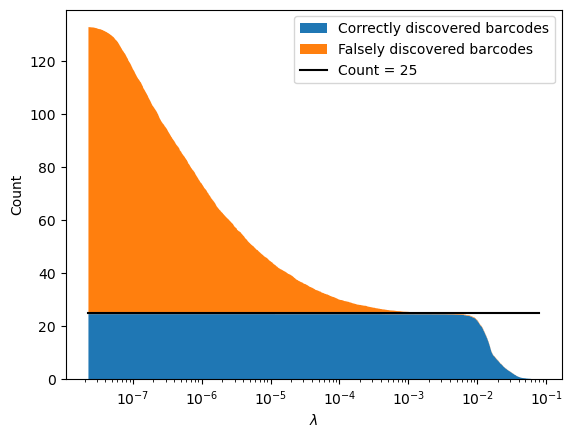

In [6]:

dcd_mpaths.set_index("rep", inplace=True, drop=False)
ground_truth.set_index("rep", inplace=True, drop=False)

rep_stats = []
for rep in np.unique(dcd_mpaths.index):
    rep_stats.append(get_eff_fdr_all_stringency(dcd_mpaths.loc[rep], ground_truth.loc[rep]))

fig, ax = plt.subplots(1)

if len(rep_stats) != 0:
    rep_stats_concat = pd.concat(rep_stats)

    rep_stats_cum_summed = cum_sums(rep_stats_concat)



    true_positives_cumsum = rep_stats_cum_summed["gene_encoding_barcodes_cumsum"] - rep_stats_cum_summed["fp_cumsum"]
    ax.stackplot(
        rep_stats_cum_summed["lambda"],
        [true_positives_cumsum/nreps, rep_stats_cum_summed["fp_cumsum"]/nreps],
        labels = ["Correctly discovered barcodes", "Falsely discovered barcodes"]
    )

    plt.plot([np.min(rep_stats_cum_summed["lambda"]), np.max(rep_stats_cum_summed["lambda"])], [nbarcodes, nbarcodes], "-k", label = "Count = {bct}".format(bct = nbarcodes))

ax.set_xscale("log")
ax.set_xlabel("$\lambda$")
ax.set_ylabel("Count")
ax.legend()

#print("saving...")
#plt.savefig(snakemake.output[0])
#plt.savefig(snakemake.output[1])
print("done")

In [7]:
from matplotlib.font_manager import FontProperties

font = FontProperties(
    family='Arial',
    size=7,
)


<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
C:\Users\jonat\AppData\Local\Temp\ipykernel_35180\3669241636.py:20: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel("$\lambda$", font = "Arial", size = 7)


saving...
done


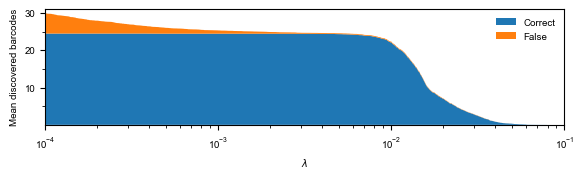

In [8]:
fig, ax = plt.subplots(1, figsize=(6.7,1.5))

if len(rep_stats) != 0:
    rep_stats_concat = pd.concat(rep_stats)

    rep_stats_cum_summed = cum_sums(rep_stats_concat)



    true_positives_cumsum = rep_stats_cum_summed["gene_encoding_barcodes_cumsum"] - rep_stats_cum_summed["fp_cumsum"]
    ax.stackplot(
        rep_stats_cum_summed["lambda"],
        [true_positives_cumsum/nreps, rep_stats_cum_summed["fp_cumsum"]/nreps],
        labels = ["Correct", "False"]
    )

    #plt.plot([np.min(rep_stats_cum_summed["lambda"]), np.max(rep_stats_cum_summed["lambda"])], [nbarcodes, nbarcodes], "-k", label = "Count = {bct}".format(bct = nbarcodes))

ax.set_xscale("log")
ax.set_xlabel("$\lambda$", font = "Arial", size = 7)
ax.set_xlim(10**-4, 10**-1)
ax.set_ylim(0, 31)
ax.set_ylabel("Mean discovered barcodes", font = "Arial", size = 7)
plt.xticks(font = "Arial", size = 7)
plt.yticks([10, 20, 30], font = "Arial", size = 7)
plt.yticks([5,15,25],minor=True)
#ax.legend(bbox_to_anchor=(1.0,1.0), frameon=False, prop=font)
ax.legend(frameon=False, prop=font)

print("saving...")
plt.savefig("lambda_path_plot.png")
plt.savefig("lambda_path_plot.pdf")
print("done")